In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection

In [5]:
claiments_data = pd.read_csv("claiments.csv")
claiments_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [6]:
claiments_data.shape

(1340, 7)

In [7]:
claiments_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [8]:
189/1340

0.141044776119403

In [10]:
claiments_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [12]:
claiments_data.duplicated().sum()

np.int64(0)

In [13]:
claiments_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

In [16]:
claiments_data.dropna(inplace=True)

In [23]:
x = claiments_data.drop(labels=["CASENUM","ATTORNEY"],axis=1)
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [24]:
y = claiments_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

In [108]:
y.value_counts()

ATTORNEY
0    578
1    518
Name: count, dtype: int64

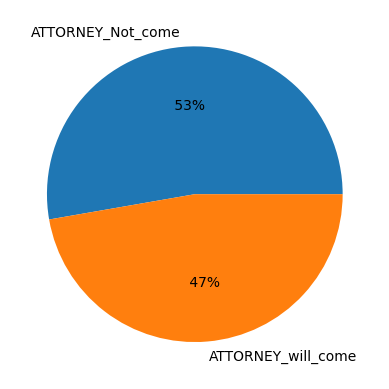

In [113]:
plt.pie(y.value_counts(),labels = ["ATTORNEY_Not_come","ATTORNEY_will_come"],autopct='% 1.0f%%')
plt.show()

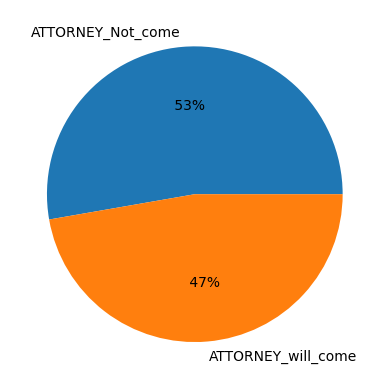

In [114]:
plt.pie(y_train.value_counts(),labels = ["ATTORNEY_Not_come","ATTORNEY_will_come"],autopct='% 1.0f%%')
plt.show()

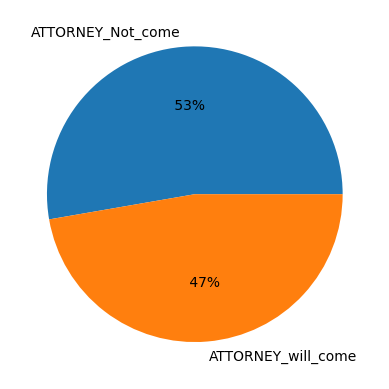

In [115]:
plt.pie(y_test.value_counts(),labels = ["ATTORNEY_Not_come","ATTORNEY_will_come"],autopct='% 1.0f%%')
plt.show()

## 5. Model Building

In [112]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20,stratify=y)

In [37]:
log_model = LogisticRegression()

## 6. Model Traning

In [72]:
grid = GridSearchCV(estimator = dt_model,param_grid={"max_depth":[4,5,6,7,8,9],"criterion":['gini','Entropy']})
grid.fit(X_train,y_train)
grid.best_score_
grid.best_params_

{'criterion': 'gini', 'max_depth': 4}

In [30]:
log_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [116]:
dt_model = DecisionTreeClassifier(max_depth=4,class_weight={0:2,1:1})

In [117]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 2, 1: 1}"


## 7. Model Testing

In [118]:
y_trt = dt_model.predict(X_train)
y_trt

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,

In [119]:
y_tet = dt_model.predict(X_test)
y_tet

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1])

## 8. Model Evaluation

In [120]:
print(classification_report(y_train,y_trt))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77       462
           1       0.77      0.62      0.68       414

    accuracy                           0.73       876
   macro avg       0.74      0.73      0.73       876
weighted avg       0.74      0.73      0.73       876



In [121]:
confusion_matrix(y_train,y_trt)

array([[386,  76],
       [159, 255]])

In [122]:
print(classification_report(y_test,y_tet))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77       116
           1       0.78      0.63      0.70       104

    accuracy                           0.74       220
   macro avg       0.75      0.74      0.74       220
weighted avg       0.75      0.74      0.74       220



In [123]:
confusion_matrix(y_test,y_tet)

array([[97, 19],
       [38, 66]])

In [126]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [128]:
print(classification_report(y_train,y_trt))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77       462
           1       0.77      0.62      0.68       414

    accuracy                           0.73       876
   macro avg       0.74      0.73      0.73       876
weighted avg       0.74      0.73      0.73       876



In [127]:
print(classification_report(y_test,y_tet))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77       116
           1       0.78      0.63      0.70       104

    accuracy                           0.74       220
   macro avg       0.75      0.74      0.74       220
weighted avg       0.75      0.74      0.74       220

